# 💼 Comparación de Modelos: KNN vs Regresión Logística
Comparamos ambos modelos usando métricas completas para determinar cuál predice mejor si una persona ganará más de 50K anuales.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

In [22]:
# Cargar y limpiar los datos
df = pd.read_csv("adult-census-income.csv")
df.replace("?", pd.NA, inplace=True)
df.dropna(inplace=True)
df['income'] = df['income'].str.strip()
df['high_income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

In [23]:
# Selección de variables y preprocesamiento
features = ['age', 'education', 'marital.status', 'occupation', 'hours.per.week', 'sex', 'native.country']
X = df[features]
y = df['high_income']

numeric_features = ['age', 'hours.per.week']
categorical_features = ['education', 'marital.status', 'occupation', 'sex', 'native.country']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Entrenar ambos modelos
knn = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', KNeighborsClassifier(n_neighbors=40))])
logreg = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000))])

knn.fit(X_train, y_train)
logreg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'hours.per.week']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['education',
                                                   'marital.status',
                                                   'occupation', 'sex',
                                                   'native.country'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [25]:
# Comparar métricas
y_pred_knn = knn.predict(X_test)
y_pred_logreg = logreg.predict(X_test)

y_prob_knn = knn.predict_proba(X_test)[:, 1]
y_prob_logreg = logreg.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy':  [accuracy_score(y_test, y_pred_knn),  accuracy_score(y_test, y_pred_logreg)],
    'Precision': [precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_logreg)],
    'Recall':    [recall_score(y_test, y_pred_knn),    recall_score(y_test, y_pred_logreg)],
    'F1-Score':  [f1_score(y_test, y_pred_knn),        f1_score(y_test, y_pred_logreg)],
    'AUC-ROC':   [roc_auc_score(y_test, y_prob_knn),   roc_auc_score(y_test, y_prob_logreg)],
}

df_metrics = pd.DataFrame(metrics, index=['KNN', 'Regresión Logística']).T
print(df_metrics.to_string(float_format="%.3f"))

            KNN  Regresión Logística
Accuracy  0.824                0.821
Precision 0.670                0.674
Recall    0.575                0.541
F1-Score  0.619                0.601
AUC-ROC   0.877                0.874


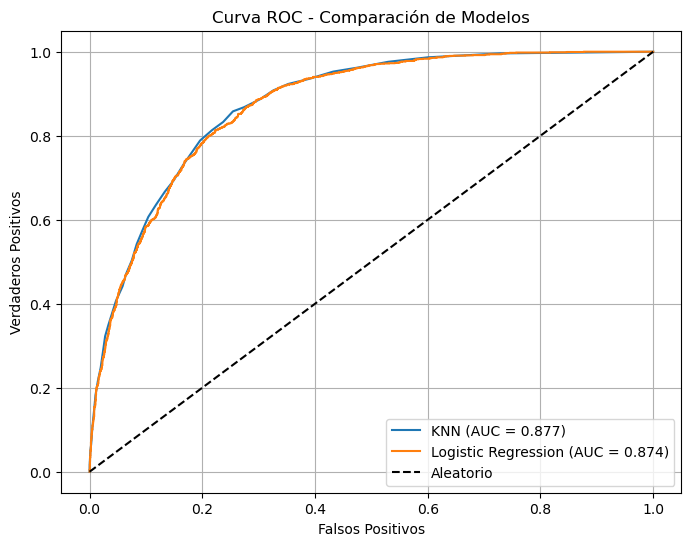

In [26]:
# Curva ROC comparada
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {metrics["AUC-ROC"][0]:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {metrics["AUC-ROC"][1]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend()
plt.grid(True)
plt.show()

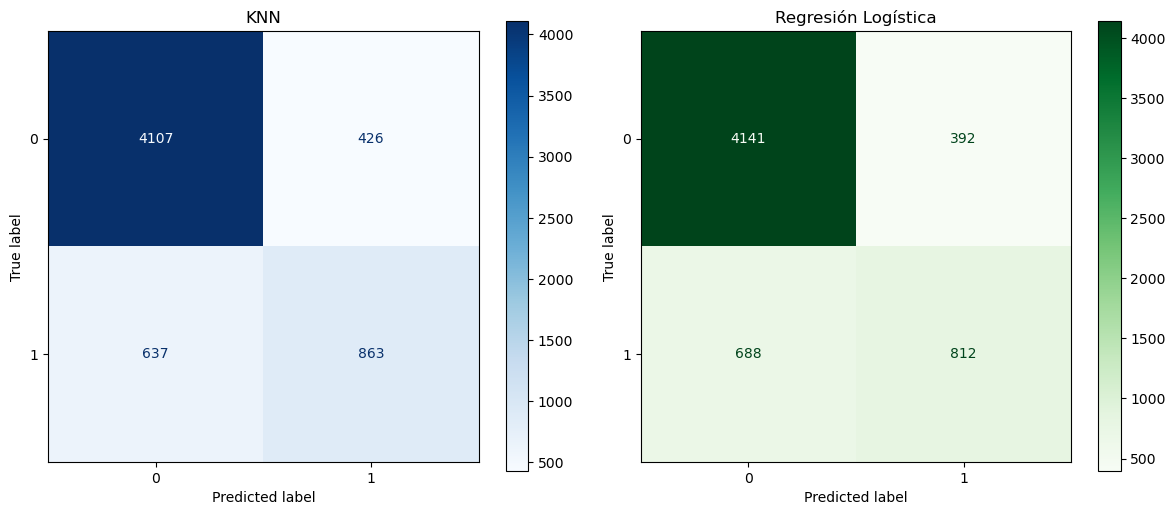

In [27]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('KNN')

ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test, ax=axes[1], cmap='Greens')
axes[1].set_title('Regresión Logística')

plt.tight_layout()
plt.show()

In [28]:
# Conclusión
winner = 'KNN' if metrics['AUC-ROC'][0] > metrics['AUC-ROC'][1] else 'Regresión Logística'
print(f"El modelo con mejor AUC-ROC es: {winner}")
print("\nInterpretación:")
print("- Accuracy: % de predicciones correctas")
print("- Precision: de los que predice >50K, cuántos realmente lo son")
print("- Recall: de los que realmente son >50K, cuántos detecta")
print("- F1-Score: balance entre precision y recall")
print("- AUC-ROC: capacidad de distinguir entre clases (1.0 = perfecto, 0.5 = aleatorio)")

El modelo con mejor AUC-ROC es: KNN

Interpretación:
- Accuracy: % de predicciones correctas
- Precision: de los que predice >50K, cuántos realmente lo son
- Recall: de los que realmente son >50K, cuántos detecta
- F1-Score: balance entre precision y recall
- AUC-ROC: capacidad de distinguir entre clases (1.0 = perfecto, 0.5 = aleatorio)
